# 🔧 Notebook 2: Data Cleaning & Preprocessing

## Fake Instagram Profile Detection System
### Final Year Project — Computer Science, GCUF

---

**Purpose:** Document every preprocessing decision made, with before/after comparisons.

**Steps covered:**
1. Load raw dataset
2. Remove duplicates
3. Handle missing values
4. Feature engineering (7 derived features)
5. Normalize features (StandardScaler)
6. Encode labels
7. Handle class imbalance (SMOTE)
8. Train/test split (80/20 stratified)
9. Save processed data
10. Summary

## 1. Import Libraries and Load Raw Dataset

We start by importing all necessary libraries and loading the raw InstaFake dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Add project root to path so we can import our modules
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

from core.feature_extractor import FeatureExtractor, FEATURE_NAMES

print('✅ Libraries imported')
print(f'Feature names: {FEATURE_NAMES}')

✅ Libraries imported
Feature names: ['followerRatio', 'profileCompleteness', 'engagementRate', 'bioLength', 'usernameAnomalyScore', 'postFrequency', 'hasPicture']


In [2]:
# Load raw dataset
DATA_PATH = os.path.join('..', 'data', 'instafake_dataset.csv')
df_raw = pd.read_csv(DATA_PATH)

print(f'📊 Raw dataset shape: {df_raw.shape}')
print(f'   Rows: {df_raw.shape[0]:,}')
print(f'   Columns: {df_raw.shape[1]}')
df_raw.head()

📊 Raw dataset shape: (1194, 9)
   Rows: 1,194
   Columns: 9


,user_media_count,user_follower_count,user_following_count,user_has_profil_pic,user_is_private,user_biography_length,username_length,username_digit_count,is_fake
0,0,25,1937,1,1,0,10,0,1
1,0,324,4122,1,0,0,15,4,1
2,0,15,399,0,0,0,12,3,1
3,1,14,107,1,0,0,10,1,1
4,0,264,4651,1,0,0,14,0,1


## 2. Step 1 — Remove Duplicates

Duplicate records can bias the model by giving extra weight to certain data points.
We remove any exact duplicate rows.

In [3]:
# Check for duplicates
n_duplicates = df_raw.duplicated().sum()
print(f'Duplicates found: {n_duplicates}')
print(f'Shape BEFORE removing duplicates: {df_raw.shape}')

# Remove duplicates
df = df_raw.drop_duplicates().reset_index(drop=True)

print(f'Shape AFTER removing duplicates:  {df.shape}')
print(f'Rows removed: {len(df_raw) - len(df)}')

Duplicates found: 29
Shape BEFORE removing duplicates: (1194, 9)
Shape AFTER removing duplicates:  (1165, 9)
Rows removed: 29


## 3. Step 2 — Handle Missing Values

Missing values can cause errors during model training. We'll:
1. Show missing value counts before treatment
2. Apply median imputation for numeric columns
3. Confirm zero missing values after treatment

In [4]:
# Missing values BEFORE
print('=== Missing Values BEFORE Treatment ===')
missing_before = df.isnull().sum()
print(missing_before)
print(f'\nTotal missing: {missing_before.sum()}')

=== Missing Values BEFORE Treatment ===
user_media_count         0
user_follower_count      0
user_following_count     0
user_has_profil_pic      0
user_is_private          0
user_biography_length    0
username_length          0
username_digit_count     0
is_fake                  0
dtype: int64

Total missing: 0


In [5]:
# Apply imputation
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f'  Filled {col} with median = {median_val}')
        else:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            print(f'  Filled {col} with mode = {mode_val}')

# Missing values AFTER
print('\n=== Missing Values AFTER Treatment ===')
missing_after = df.isnull().sum()
print(missing_after)
print(f'\nTotal missing: {missing_after.sum()}')
assert missing_after.sum() == 0, 'There are still missing values!'
print('\n✅ Confirmed: Zero missing values.')


=== Missing Values AFTER Treatment ===
user_media_count         0
user_follower_count      0
user_following_count     0
user_has_profil_pic      0
user_is_private          0
user_biography_length    0
username_length          0
username_digit_count     0
is_fake                  0
dtype: int64

Total missing: 0

✅ Confirmed: Zero missing values.


## 4. Step 3 — Feature Engineering

We create 7 derived features from the raw dataset columns. These features capture
meaningful patterns that help distinguish fake from genuine profiles:

| Derived Feature | Computation |
|---|---|
| `followerRatio` | followers / (following + 1) |
| `profileCompleteness` | composite score from pic, bio, etc. |
| `engagementRate` | posts / (followers + 1) |
| `bioLength` | biography character count |
| `usernameAnomalyScore` | digit ratio + length penalty |
| `postFrequency` | total post count |
| `hasPicture` | 1.0 if profile pic exists |

In [6]:
# Find label column
label_col = 'is_fake' if 'is_fake' in df.columns else df.columns[-1]
print(f'Label column: {label_col}')

# Engineer features
extractor = FeatureExtractor()
features_list = []
for _, row in df.iterrows():
    features_list.append(extractor.extract_from_dataset_row(row))

X = pd.DataFrame(features_list, columns=FEATURE_NAMES)
y = df[label_col].astype(int)

print(f'\n📊 Engineered features shape: {X.shape}')
print(f'   Feature names: {list(X.columns)}')
print(f'\n--- First 5 rows of engineered features ---')
X.head()

Label column: is_fake

📊 Engineered features shape: (1165, 7)
   Feature names: ['followerRatio', 'profileCompleteness', 'engagementRate', 'bioLength', 'usernameAnomalyScore', 'postFrequency', 'hasPicture']

--- First 5 rows of engineered features ---


,followerRatio,profileCompleteness,engagementRate,bioLength,usernameAnomalyScore,postFrequency,hasPicture
0,0.012900,0.50,0.000000,0.0,0.000000,0.0,1.0
1,0.078584,0.50,0.000000,0.0,0.125000,0.0,1.0
2,0.037500,0.15,0.000000,0.0,0.115385,0.0,0.0
3,0.129630,0.50,0.066667,0.0,0.045455,1.0,1.0
4,0.056750,0.50,0.000000,0.0,0.000000,0.0,1.0


In [7]:
# Summary statistics of engineered features
X.describe().T

,count,mean,std,min,25%,50%,75%,max
followerRatio,1165.0,0.802605,0.770766,0.00,0.461538,0.832998,1.000000,15.272727
profileCompleteness,1165.0,0.637039,0.199773,0.15,0.500000,0.750000,0.850000,0.850000
engagementRate,1165.0,0.184891,0.559381,0.00,0.017668,0.066667,0.169231,9.000000
bioLength,1165.0,22.626609,33.291338,0.00,0.000000,7.000000,33.000000,150.000000
usernameAnomalyScore,1165.0,0.021814,0.052836,0.00,0.000000,0.000000,0.000000,0.416667
postFrequency,1165.0,57.484979,108.195266,0.00,3.000000,19.000000,66.000000,1058.000000
hasPicture,1165.0,0.921030,0.269808,0.00,1.000000,1.000000,1.000000,1.000000


## 5. Step 4 — Normalize Features

We use StandardScaler to normalize all features to have mean=0 and std=1.
This is important because:
- SVM and Logistic Regression are sensitive to feature scales
- It ensures all features contribute equally during training

**We save the scaler as `models/scaler.pkl` for use during live predictions.**

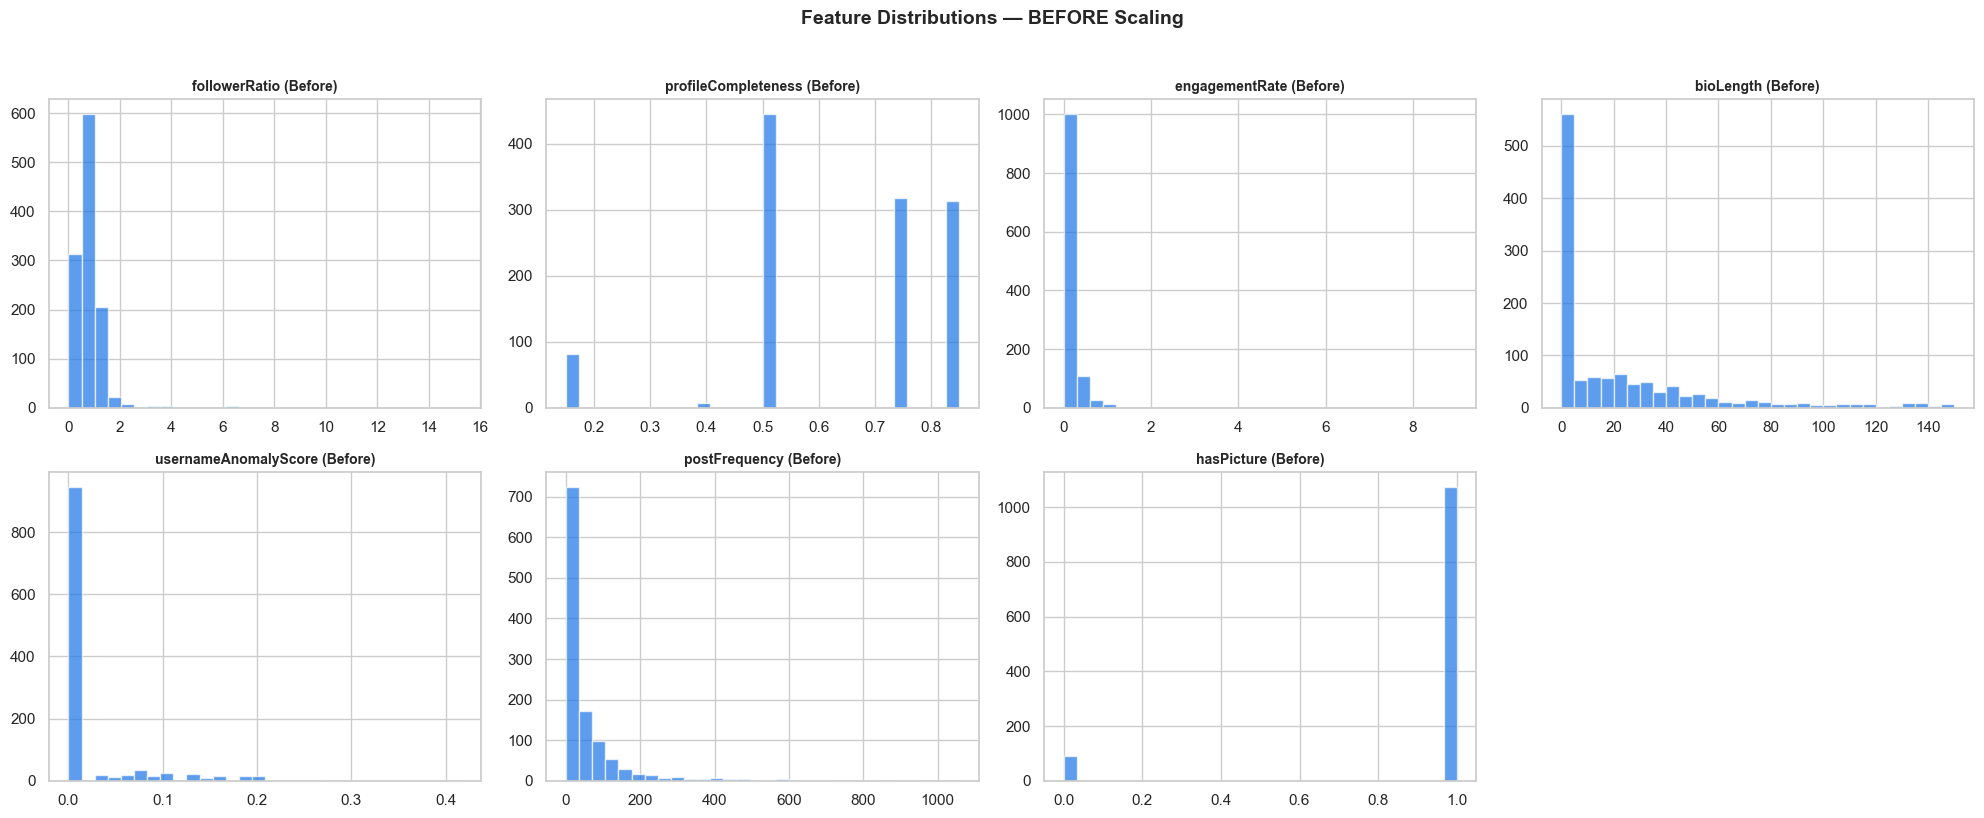

In [8]:
from sklearn.preprocessing import StandardScaler
import joblib

# First, let's visualize distributions BEFORE scaling
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(FEATURE_NAMES):
    axes[i].hist(X[feature], bins=30, color='#1a73e8', alpha=0.7, edgecolor='white')
    axes[i].set_title(f'{feature} (Before)', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

if len(FEATURE_NAMES) < 8:
    axes[-1].set_visible(False)

plt.suptitle('Feature Distributions — BEFORE Scaling', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

💾 Scaler saved to ..\models\scaler.pkl


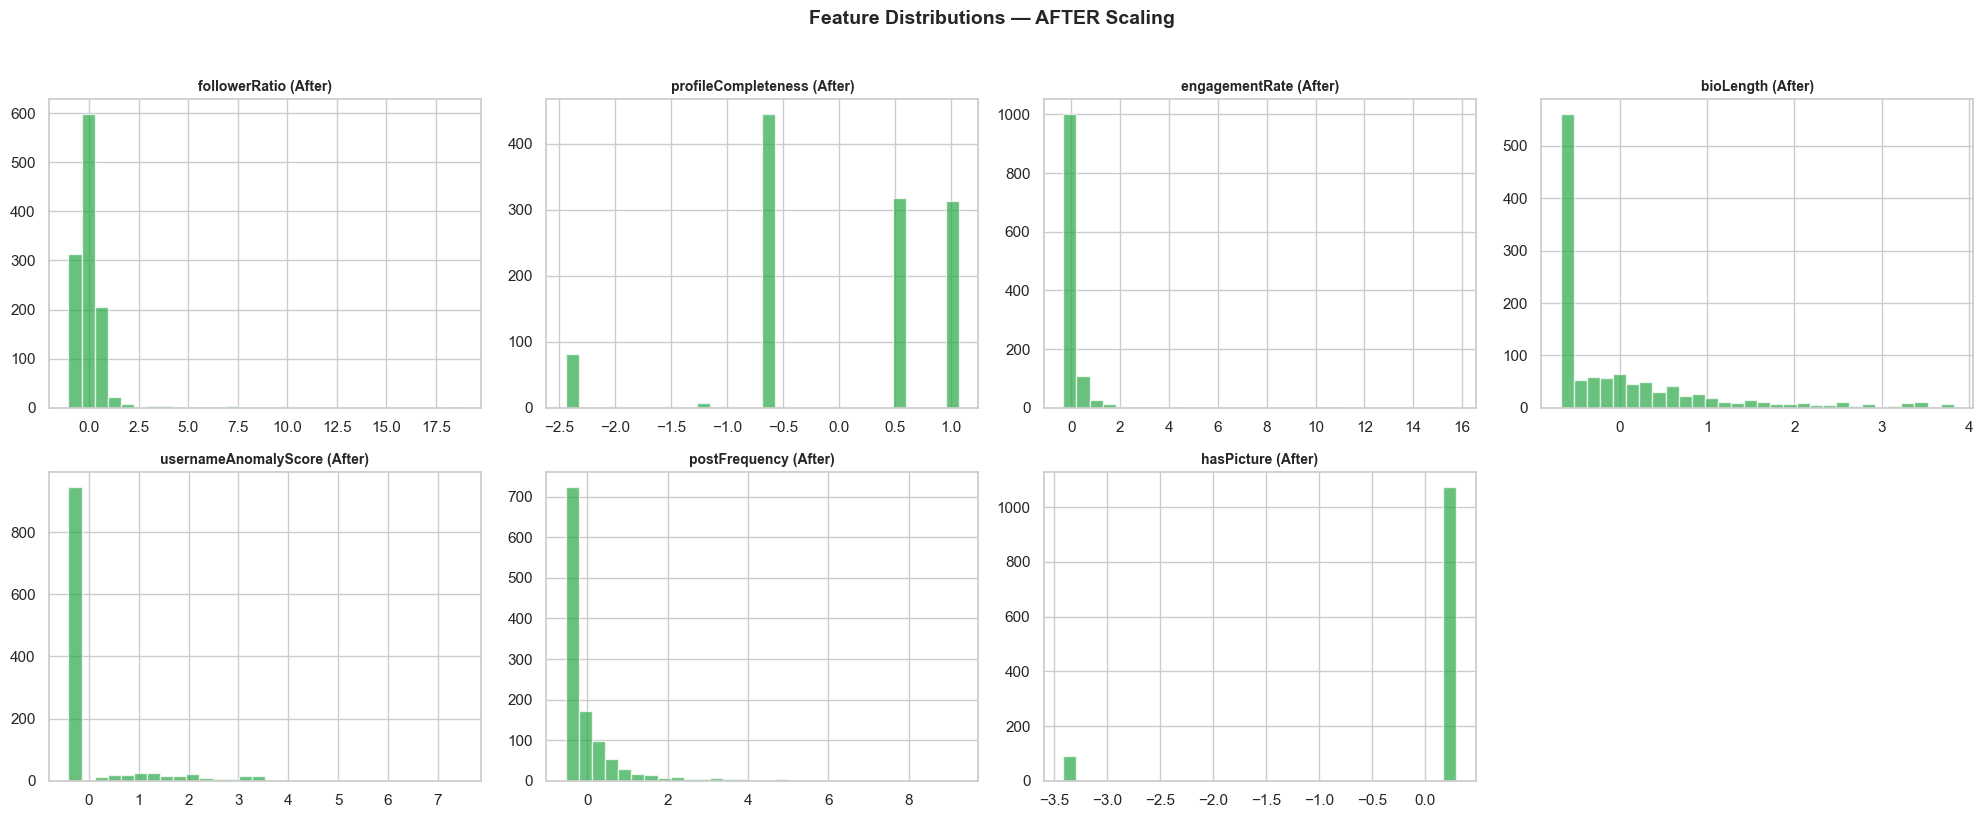


Scaled feature statistics:
Mean: [0. 0. 0. 0. 0. 0. 0.]
Std:  [1. 1. 1. 1. 1. 1. 1.]


In [9]:
# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURE_NAMES)

# Save scaler
MODELS_DIR = os.path.join('..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)
scaler_path = os.path.join(MODELS_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f'💾 Scaler saved to {scaler_path}')

# Visualize distributions AFTER scaling
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(FEATURE_NAMES):
    axes[i].hist(X_scaled_df[feature], bins=30, color='#28a745', alpha=0.7, edgecolor='white')
    axes[i].set_title(f'{feature} (After)', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

if len(FEATURE_NAMES) < 8:
    axes[-1].set_visible(False)

plt.suptitle('Feature Distributions — AFTER Scaling', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Verify mean ≈ 0 and std ≈ 1
print('\nScaled feature statistics:')
print(f'Mean: {X_scaled.mean(axis=0).round(4)}')
print(f'Std:  {X_scaled.std(axis=0).round(4)}')

## 6. Step 5 — Encode Labels

We confirm that the label column is already binary (0 = genuine, 1 = fake).

In [10]:
# Verify labels
y = y.astype(int)
print('Label value counts:')
print(y.value_counts())
print(f'\nUnique values: {sorted(y.unique())}')
assert set(y.unique()) <= {0, 1}, 'Labels are not binary!'
print('\n✅ Labels confirmed as binary (0/1).')

Label value counts:
is_fake
0    965
1    200
Name: count, dtype: int64

Unique values: [np.int64(0), np.int64(1)]

✅ Labels confirmed as binary (0/1).


## 7. Step 6 — Handle Class Imbalance (SMOTE)

If the dataset is imbalanced, SMOTE (Synthetic Minority Over-sampling Technique)
creates synthetic samples for the minority class to balance the training data.

**Important:** We apply SMOTE only to the training set (after split), not the test set.

In [11]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Split first (SMOTE only on training data)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Class counts BEFORE SMOTE
print('=== Class Counts BEFORE SMOTE (Training Set) ===')
train_counts_before = pd.Series(y_train).value_counts()
print(train_counts_before)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Class counts AFTER SMOTE
print('\n=== Class Counts AFTER SMOTE (Training Set) ===')
train_counts_after = pd.Series(y_train_res).value_counts()
print(train_counts_after)

=== Class Counts BEFORE SMOTE (Training Set) ===
is_fake
0    772
1    160
Name: count, dtype: int64

=== Class Counts AFTER SMOTE (Training Set) ===
is_fake
0    772
1    772
Name: count, dtype: int64


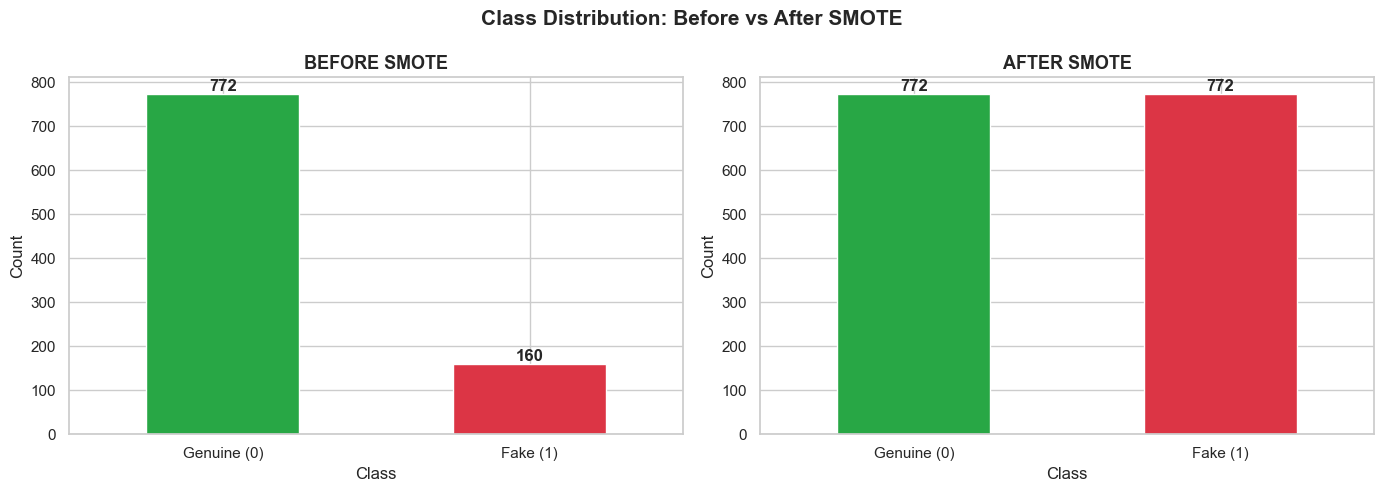

In [12]:
# Visualize before vs after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
train_counts_before.plot(kind='bar', ax=axes[0], color=['#28a745', '#dc3545'])
axes[0].set_title('BEFORE SMOTE', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Genuine (0)', 'Fake (1)'], rotation=0)
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height()):,}',
                     (bar.get_x() + bar.get_width()/2., bar.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# After
train_counts_after.plot(kind='bar', ax=axes[1], color=['#28a745', '#dc3545'])
axes[1].set_title('AFTER SMOTE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Genuine (0)', 'Fake (1)'], rotation=0)
for bar in axes[1].patches:
    axes[1].annotate(f'{int(bar.get_height()):,}',
                     (bar.get_x() + bar.get_width()/2., bar.get_height()),
                     ha='center', va='bottom', fontweight='bold')

plt.suptitle('Class Distribution: Before vs After SMOTE', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Step 7 — Train/Test Split

We already performed the split before SMOTE. Let's confirm the shapes and class distributions.

In [13]:
print('=== Train/Test Split Summary ===')
print(f'X_train shape (after SMOTE): {X_train_res.shape}')
print(f'X_test shape:                {X_test.shape}')
print(f'y_train shape (after SMOTE): {y_train_res.shape}')
print(f'y_test shape:                {y_test.shape}')

print(f'\nTrain class distribution (after SMOTE):')
print(pd.Series(y_train_res).value_counts())

print(f'\nTest class distribution (original — no SMOTE):')
print(pd.Series(y_test).value_counts())

# Verify stratification in test set
test_pct = pd.Series(y_test).value_counts(normalize=True)
print(f'\nTest set class percentages:')
for cls, pct in test_pct.items():
    label = 'Fake' if cls == 1 else 'Genuine'
    print(f'  {label}: {pct:.1%}')

=== Train/Test Split Summary ===
X_train shape (after SMOTE): (1544, 7)
X_test shape:                (233, 7)
y_train shape (after SMOTE): (1544,)
y_test shape:                (233,)

Train class distribution (after SMOTE):
is_fake
0    772
1    772
Name: count, dtype: int64

Test class distribution (original — no SMOTE):
is_fake
0    193
1     40
Name: count, dtype: int64

Test set class percentages:
  Genuine: 82.8%
  Fake: 17.2%


## 9. Save Processed Data

We save the processed train and test sets as CSV files for use in Notebook 3 (Training & Evaluation).

In [14]:
# Save processed data
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Save as DataFrames with column names
pd.DataFrame(X_train_res, columns=FEATURE_NAMES).to_csv(
    os.path.join(PROCESSED_DIR, 'X_train.csv'), index=False
)
pd.DataFrame(X_test, columns=FEATURE_NAMES).to_csv(
    os.path.join(PROCESSED_DIR, 'X_test.csv'), index=False
)
pd.Series(y_train_res, name='label').to_csv(
    os.path.join(PROCESSED_DIR, 'y_train.csv'), index=False
)
pd.Series(y_test, name='label').to_csv(
    os.path.join(PROCESSED_DIR, 'y_test.csv'), index=False
)

print('💾 Saved processed data to data/processed/')
for f in os.listdir(PROCESSED_DIR):
    size = os.path.getsize(os.path.join(PROCESSED_DIR, f))
    print(f'  {f}: {size:,} bytes')

💾 Saved processed data to data/processed/
  X_test.csv: 32,790 bytes
  X_train.csv: 216,611 bytes
  y_test.csv: 706 bytes
  y_train.csv: 4,639 bytes


## 10. Preprocessing Summary

### Decisions Made and Justifications:

| Step | Decision | Justification |
|---|---|---|
| Duplicates | Removed exact duplicates | Prevents artificial bias |
| Missing Values | Median imputation (numeric), Mode (categorical) | Robust to outliers |
| Feature Engineering | 7 derived features from raw columns | Captures meaningful patterns (ratios, completeness, anomaly scores) |
| Normalization | StandardScaler (z-score) | Required for SVM/LR; ensures equal feature weighting |
| Label Encoding | Confirmed binary (0/1) | Already in correct format |
| Class Imbalance | SMOTE on training set only | Avoids data leakage; balances classes for fair training |
| Train/Test Split | 80/20 stratified split | Preserves class distribution in both sets |
| Scaler Saved | `models/scaler.pkl` | Critical for transforming live prediction inputs identically |

---

**Next Steps:**
- Proceed to **Notebook 03: Model Training & Evaluation**
- Load the preprocessed data
- Train all 4 models: Random Forest, SVM, Logistic Regression, XGBoost
- Compare performance and select the best model